# ISIC 2019 — Entrenamiento Expert 2: EfficientNet-B3

**Objetivo**: Entrenar un clasificador de 8 clases para el dataset ISIC 2019 usando
EfficientNet-B3 como backbone, con fine-tuning en dos fases.

**Arquitectura**: EfficientNet-B3 (pretrained ImageNet) + Custom Head

**Estrategia de entrenamiento**:
- **Fase A (Feature Extraction)**: Backbone congelado, solo cabeza clasificadora. 10 épocas, LR=1e-3.
- **Fase B (Fine-Tuning)**: Últimos 3 bloques del backbone desbloqueados. 30 épocas, LR=1e-5.

**Loss**: FocalLoss (gamma=2.0) con class weights para imbalance severo.

**Sampler**: WeightedRandomSampler para balancear batches.

**Métricas**: Accuracy, F1-Score (Macro/Weighted), AUC-ROC, Confusion Matrix.

**Referencias**: Proyecto MoE (Exp. 2), paper DVFNet (PLOS ONE 2024), Osteoarthritis VGG16BN Training.

---

## FASE 0: Setup, Imports y Reproducción del Pipeline EDA

In [ ]:
!pip install -q monai timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 7.6 MB/s eta 0:00:00


### Configuración del Entorno de Alto Rendimiento y Reproducibilidad

Se ha establecido un **entorno de ejecución optimizado** mediante la integración de las librerías **PyTorch, TIMM y MONAI**, asegurando la estabilidad y reproducibilidad total del experimento:

* **Garantía de Reproducibilidad:** Se fijó la semilla aleatoria (**SEED 42**) en todos los componentes del sistema. Esta cimentación técnica es vital, ya que ajusta los parámetros de **cuDNN** para eliminar variaciones estocásticas, asegurando que cada diagnóstico dependa exclusivamente de la arquitectura neuronal.
* **Gestión de Recursos de Hardware:** El sistema verifica la disponibilidad de la **GPU** y la capacidad de la **VRAM**, preparando el terreno para:
    * **Precisión Mixta (Autocast):** Para optimizar el uso de memoria y acelerar el entrenamiento.
    * **Transformaciones Médicas Especializadas:** Aprovechando las capacidades de MONAI para el procesamiento de imágenes clínicas.
* **Optimización del Flujo de Datos:** Se configuró el manejo de redes complejas evitando el agotamiento de los recursos del sistema, con el objetivo final de obtener **métricas de clasificación estables y fiables**.

In [ ]:
import os, time, shutil, zipfile, glob, random, warnings, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import timm
import monai
import monai.data
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd,
    NormalizeIntensityd, RandFlipd, ToTensord, Lambdad,
)

from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ---------- Reproducibilidad ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Dispositivo: cuda
GPU: Tesla T4
VRAM total: 15.6 GB


## 0.1 Montar Drive y Preparar Dataset

### Gestión Dinámica de Activos y Persistencia

Implementamos una fase de **GESTIÓN DINÁMICA DE ACTIVOS** para optimizar la transferencia de datos desde Google Drive hacia el entorno local de Colab, reduciendo drásticamente los tiempos de lectura de las **25,000 imágenes del dataset ISIC 2019**. 

El proceso consistió en:
* **Automatizar la COPIA Y DESCOMPRESIÓN** del archivo ZIP original.
* **Creación de un directorio de pesos (WEIGHTS_DIR)** para garantizar la persistencia del modelo. 

Para blindar el código contra fallos en la estructura de carpetas, incluimos un **algoritmo de ESCANEO RECURSIVO** que localiza automáticamente:
1. El archivo `GroundTruth.csv`.
2. El directorio de imágenes.

Esto permite que el flujo de entrenamiento se inicie **sin errores de ruta**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# --- Rutas ---
ZIP_DRIVE     = '/content/drive/MyDrive/DataProyecto2/ISIC 2019.zip'
ZIP_LOCAL     = '/content/ISIC_2019.zip'
DESTINO_LOCAL = '/content/isic2019/'
WEIGHTS_DIR   = '/content/drive/MyDrive/DataProyecto2/Weights/'
os.makedirs(WEIGHTS_DIR, exist_ok=True)

if os.path.exists(DESTINO_LOCAL) and len(os.listdir(DESTINO_LOCAL)) > 0:
    print('Dataset ya descomprimido. Saltando.')
else:
    print('Copiando ZIP ...')
    start = time.time()
    shutil.copy2(ZIP_DRIVE, ZIP_LOCAL)
    print(f'Copiado en {time.time()-start:.1f}s. Descomprimiendo...')
    start = time.time()
    os.makedirs(DESTINO_LOCAL, exist_ok=True)
    !unzip -q '{ZIP_LOCAL}' -d '{DESTINO_LOCAL}'
    os.remove(ZIP_LOCAL)
    print(f'Descomprimido en {time.time()-start:.1f}s')

# Localizar directorio de imágenes y CSV
IMG_DIR = os.path.join(DESTINO_LOCAL, 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input')
CSV_PATH = os.path.join(DESTINO_LOCAL, 'ISIC_2019_Training_GroundTruth.csv')

if not os.path.isdir(IMG_DIR):
    for root, dirs, files in os.walk(DESTINO_LOCAL):
        jpgs = [f for f in files if f.lower().endswith('.jpg')]
        if len(jpgs) > 100:
            IMG_DIR = root
            break

if not os.path.isfile(CSV_PATH):
    for root, dirs, files in os.walk(DESTINO_LOCAL):
        for f in files:
            if 'GroundTruth' in f and f.endswith('.csv'):
                CSV_PATH = os.path.join(root, f)
                break

print(f'IMG_DIR : {IMG_DIR}')
print(f'CSV_PATH: {CSV_PATH}')
print(f'Imágenes encontradas: {len(glob.glob(os.path.join(IMG_DIR, "*.jpg")))}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copiando ZIP ...
Copiado en 163.8s. Descomprimiendo...
Descomprimido en 131.0s
IMG_DIR : /content/isic2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input
CSV_PATH: /content/isic2019/ISIC_2019_Training_GroundTruth.csv
Imágenes encontradas: 25331


---
## FASE 1: Carga de Etiquetas y Preparación de Datos

### Arquitectura de Parámetros e Integridad de Datos

Establecimos una **ARQUITECTURA DE PARÁMETROS** crítica para el entrenamiento, definiendo:
* **Esquema de dos fases:** Con **LEARNING RATES diferenciados** para optimizar la convergencia.
* **Sistema de EARLY STOPPING:** Con una paciencia de **7 épocas** para evitar el sobreajuste.

En cuanto a la limpieza de datos, ejecutamos los siguientes procesos:
1. **Filtrado de ETIQUETAS EXCLUYENTES:** Se eliminaron las muestras marcadas como **'UNK'** (desconocidas).
2. **VALIDACIÓN DE EXISTENCIA FÍSICA:** Vincula cada registro del CSV con su **archivo de imagen real en disco**.

Este proceso es **VITAL** para garantizar la integridad del flujo tensor, pues:
* Transforma una tabla de metadatos en un **inventario de 8 clases diagnósticas** perfectamente mapeadas y verificadas.
* Permite que la red neuronal se enfoque exclusivamente en **aprender patrones visuales** sin riesgo de errores por archivos corruptos o categorías ambiguas.

In [ ]:
# --- Parámetros ---
NUM_CLASSES     = 8
IMG_SIZE        = 224
BATCH_SIZE      = 64
NUM_WORKERS     = 2
EPOCHS_A        = 5
EPOCHS_B        = 30
LR_A            = 1e-3
LR_B            = 3e-4
PATIENCE        = 7
FOCAL_GAMMA     = 2.0
VAL_SPLIT       = 0.20

# ImageNet stats
DATASET_MEAN = np.array([0.485, 0.456, 0.406])
DATASET_STD  = np.array([0.229, 0.224, 0.225])

# --- Clases (8 sin UNK) ---
CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
label_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

# --- Cargar CSV ---
df = pd.read_csv(CSV_PATH)
print(f'Total filas CSV: {len(df)}')

# Eliminar UNK si existe
if 'UNK' in df.columns:
    df = df[df['UNK'] != 1.0].reset_index(drop=True)
    print(f'Filas tras eliminar UNK: {len(df)}')

# Obtener etiqueta de cada fila
available_cols = [c for c in CLASS_NAMES if c in df.columns]
label_df = df[available_cols]

df['label_name'] = label_df.idxmax(axis=1)
df['label'] = df['label_name'].map(label_to_idx)

# Verificar que todas las imágenes existen
img_col = df.columns[0]  # 'image'
df['path'] = df[img_col].apply(lambda x: os.path.join(IMG_DIR, x + '.jpg'))
df['exists'] = df['path'].apply(os.path.isfile)
df = df[df['exists']].reset_index(drop=True)
print(f'Imágenes válidas: {len(df)}')

# Distribución
print('\nDistribución de clases:')
for i, c in enumerate(CLASS_NAMES):
    cnt = (df['label'] == i).sum()
    print(f'  {c}: {cnt}')

Total filas CSV: 25331
Filas tras eliminar UNK: 25331
Imágenes válidas: 25331

Distribución de clases:
  MEL: 4522
  NV: 12875
  BCC: 3323
  AK: 867
  BKL: 2624
  DF: 239
  VASC: 253
  SCC: 628


---
## FASE 2: Split Train/Val y Balanceo

### Estrategia de Compensación Dual y Balanceo de Clases

Para corregir el desbalance natural de las patologías, implementamos una **ESTRATEGIA DE COMPENSACIÓN DUAL** mediante un split estratificado que conserva la proporción de las 8 clases en los grupos de control. 

El núcleo del proceso se basa en los siguientes pilares técnicos:

* **Cálculo de PESOS DE CLASE INVERSOS:** Diseñados para que la función de pérdida penalice con mayor severidad los errores en diagnósticos poco frecuentes como el **Carcinoma (SCC)** o el **Dermatofibroma (DF)**.
* **WEIGHTED RANDOM SAMPLER:** Al integrar estos pesos, forzamos a la red neuronal a ver ejemplos de todas las categorías en cada lote, evitando que el modelo se sesgue hacia la clase mayoritaria (**Nevus**).
* **Compatibilidad con MONAI:** Estructuramos los datos en diccionarios compatibles con la librería, transformando una base de datos desequilibrada en un **flujo de entrenamiento simétrico y robusto**.

Esta configuración es **VITAL** para que la IA desarrolle una **sensibilidad clínica uniforme** ante lesiones raras y comunes por igual.

In [ ]:
# --- Split estratificado ---
train_df, val_df = train_test_split(
    df, test_size=VAL_SPLIT, stratify=df['label'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f'Train: {len(train_df)}, Val: {len(val_df)}')

# --- Class weights para FocalLoss ---
train_labels = train_df['label'].values
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'\nClass weights: {class_weights.cpu().numpy().round(3)}')

# --- WeightedRandomSampler para balancear batches ---
sample_weights = class_weights[torch.tensor(train_labels, dtype=torch.long)].cpu().numpy()
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# --- Diccionarios MONAI ---
train_dicts = [{'image': row['path'], 'label': int(row['label'])} for _, row in train_df.iterrows()]
val_dicts   = [{'image': row['path'], 'label': int(row['label'])} for _, row in val_df.iterrows()]
print(f'\nTrain dicts: {len(train_dicts)}, Val dicts: {len(val_dicts)}')

Train: 20264, Val: 5067

Class weights: [0.149 0.052 0.203 0.777 0.257 2.821 2.668 1.073]

Train dicts: 20264, Val dicts: 5067


---
## FASE 3: Transforms MONAI y DataLoaders

### Pipeline de Procesamiento Persistente y Estandarización

Para optimizar la ingesta de datos, estructuramos un **PIPELINE DE PROCESAMIENTO PERSISTENTE** utilizando la librería **MONAI**, el cual integra las siguientes etapas técnicas:

* **Transformaciones de Carga:** Ingesta automatizada de archivos médicos.
* **Reescalado Bilineal:** Ajuste dimensional a $224 \times 224$ píxeles.
* **Normalización Estadística:** Alineada con los estándares de **ImageNet** para asegurar la compatibilidad con el *backbone* preentrenado.

**Implementación de PersistentDataset**
El núcleo de esta fase es la implementación de un **PersistentDataset**, una técnica **VITAL** que:
* Genera una **caché en disco** de las imágenes ya procesadas.
* Elimina **cuellos de botella computacionales** al evitar repetir transformaciones pesadas.
* Acelera drásticamente las épocas posteriores del entrenamiento.

**Optimización del Flujo hacia la GPU**
Al configurar los **DataLoaders** con el muestreador balanceado (**sampler**) y la función de colación médica de MONAI, garantizamos:
1.  Un flujo constante de tensores listos para el cómputo.
2.  Un aprendizaje eficiente sobre un dataset dermatológico que es **rápido de leer** y está **matemáticamente estandarizado**.

In [ ]:
from monai.transforms import Resized
from monai.data import list_data_collate
spatial_axes = [0, 1]

train_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),

    Resized(keys=["image"], spatial_size=(IMG_SIZE, IMG_SIZE), mode='bilinear'),

    # Augmentation geometrica (solo flip, consistente con EDA)
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=spatial_axes),
    # Normalizacion
    ScaleIntensityd(keys=["image"]),
    NormalizeIntensityd(
        keys=["image"],
        subtrahend=[0.485, 0.456, 0.406],
        divisor=[0.229, 0.224, 0.225],
        channel_wise=True
    ),
    ToTensord(keys=["image", "label"], track_meta=False)
])

# --- VAL TRANSFORMS ---
val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),

    Resized(keys=["image"], spatial_size=(IMG_SIZE, IMG_SIZE), mode='bilinear'),

    ScaleIntensityd(keys=["image"]),
    NormalizeIntensityd(
        keys=["image"],
        subtrahend=[0.485, 0.456, 0.406],
        divisor=[0.229, 0.224, 0.225],
        channel_wise=True
    ),
    ToTensord(keys=["image", "label"], track_meta=False)
])

print("Transforms definidos OK - alineados con EDA FINAL y Resized integrado")

# --- Cache en disco para acelerar épocas posteriores ---
cache_dir = "/content/cache_isic"
os.makedirs(cache_dir, exist_ok=True)

# --- Datasets con PersistentDataset (cache en disco) ---
train_ds = monai.data.PersistentDataset(data=train_dicts, transform=train_transforms, cache_dir=cache_dir)
val_ds   = monai.data.PersistentDataset(data=val_dicts,   transform=val_transforms, cache_dir=cache_dir)

# --- DataLoaders ---
# NOTA: se usa sampler en train para balancear clases (no shuffle con sampler)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,   # <--- CAMBIAR A FALSE
    collate_fn=list_data_collate
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,   # <--- CAMBIAR A FALSE
    collate_fn=list_data_collate
)

print(f'Train DataLoader: {len(train_loader)} batches de {BATCH_SIZE}')
print(f'Val DataLoader:   {len(val_loader)} batches de {BATCH_SIZE}')

# Verificar un batch
sample_batch = next(iter(train_loader))
print(f'\nBatch shape: {sample_batch["image"].shape}')
print(f'Labels: {sample_batch["label"]}')
print(f'Rango px: [{sample_batch["image"].min():.3f}, {sample_batch["image"].max():.3f}]')

Transforms definidos OK - alineados con EDA FINAL y Resized integrado
Train DataLoader: 317 batches de 64
Val DataLoader:   80 batches de 64

Batch shape: torch.Size([64, 3, 224, 224])
Labels: tensor([5, 4, 0, 1, 5, 2, 5, 0, 7, 4, 6, 1, 2, 3, 2, 0, 0, 4, 0, 7, 4, 5, 6, 0,
        5, 1, 5, 1, 5, 7, 0, 4, 1, 4, 6, 2, 5, 4, 1, 6, 1, 3, 1, 4, 7, 4, 4, 0,
        7, 6, 0, 4, 0, 4, 6, 0, 1, 4, 3, 6, 2, 4, 3, 6])
Rango px: [-2.118, 2.640]


---
## FASE 4: Modelo EfficientNet-B3 + Focal Loss

### Arquitectura de Clasificación Avanzada

Para optimizar la capacidad de discernimiento del modelo ante lesiones cutáneas complejas, implementamos una **ARQUITECTURA DE CLASIFICACIÓN AVANZADA** basada en la red **EfficientNet-B3**, aprovechando el conocimiento previo de ImageNet mediante *transfer learning*.

El núcleo técnico de esta fase se compone de:

* **Integración de Focal Loss:** Una función de pérdida diseñada específicamente para combatir el desbalance de clases al reducir la importancia de los ejemplos fáciles y centrar el gradiente en los casos difíciles de diagnosticar.
* **Gestión del Balanceo:** Es **VITAL** destacar la decisión técnica de desactivar los pesos de clase dentro de la función de pérdida (`weight=None`) para evitar el **"double weighting"**. Esto permite que:
    1.  El **WeightedRandomSampler** gestione el balanceo de los lotes.
    2.  La **Focal Loss** se enfoque en refinar la precisión en las fronteras de decisión más ambiguas.

**Configuración del Sistema**
Con más de **10 millones de parámetros entrenables** y una estrategia de penalización dinámica, el sistema queda configurado para maximizar el **F1-Score** y la **sensibilidad clínica** en las 8 categorías.

In [ ]:
# ============================================================
# Focal Loss — manejo de imbalance severo
# ============================================================
class FocalLoss(nn.Module):
    """Focal Loss para clasificación multi-clase con class weights."""
    def __init__(self, gamma=2.0, weight=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        return focal

# ============================================================
# Modelo: EfficientNet-B3 con cabeza personalizada
# ============================================================
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)
print(f'Modelo: EfficientNet-B3')
print(f'Parámetros totales: {sum(p.numel() for p in model.parameters()):,}')

# --- FocalLoss con class weights ---
# NOTA: NO se usa double weighting. El WeightedRandomSampler balancea los batches,
# y el class_weights en FocalLoss compensa la señal de gradiente.
# FIX: No usar class_weights en FocalLoss porque WeightedRandomSampler
# ya balancea los batches. Usar ambos causa "double weighting"
# que destruye el F1-Score.
criterion = FocalLoss(gamma=FOCAL_GAMMA, weight=None)

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Modelo: EfficientNet-B3
Parámetros totales: 10,708,528


---
## FASE 5A: Entrenamiento — Feature Extraction (Backbone Congelado)

### Entrenamiento Fase A: Extracción de Características

Iniciamos el entrenamiento mediante una **ESTRATEGIA DE TRANSFERENCIA DE APRENDIZAJE** dividida en dos etapas, comenzando por la **FASE A: EXTRACCIÓN DE CARACTERÍSTICAS**. 

Los pilares técnicos de esta etapa incluyen:

* **Congelamiento del Backbone:** Procedimos a congelar la red (**EfficientNet-B3**) para preservar los pesos preentrenados en ImageNet.
* **Optimización Focalizada:** Se permite que el optimizador **ADAM** ajuste únicamente la cabeza clasificadora final (*custom head*).
* **Eficiencia de Hardware:** Para maximizar el rendimiento sin sacrificar la precisión, implementamos un bucle de entrenamiento con **PRECISIÓN MIXTA (GradScaler)**, lo que reduce el uso de memoria de la GPU y acelera el cálculo de gradientes.

**Propósito Clínico y Técnico**
Esta fase es **VITAL** para:
1.  **Alinear representaciones:** Adaptar las características visuales genéricas a las **8 clases dermatológicas** específicas del proyecto.
2.  **Estabilidad Inicial:** Establecer una base sólida de clasificación antes de permitir que la red completa se adapte a las sutilezas morfológicas de las lesiones cutáneas.
3.  **Monitoreo Constante:** Se supervisa la pérdida y la exactitud en entrenamiento y validación para asegurar un aprendizaje estable y controlado.

In [ ]:
# --- Congelar backbone ---
for name, param in model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable_a = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params entrenables (feature extraction): {trainable_a:,}')

optimizer_a = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR_A
)

# --- Training Loop Phase A ---
scaler = GradScaler()
history_a = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(EPOCHS_A):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch in train_loader:
        imgs = batch['image'].to(device)
        lbls = batch['label'].to(device)
        optimizer_a.zero_grad()
        with autocast():
            out = model(imgs)
            loss = criterion(out, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer_a)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == lbls).sum().item()
        total += imgs.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # Validación
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch['image'].to(device)
            lbls = batch['label'].to(device)
            with autocast():
                out = model(imgs)
                loss = criterion(out, lbls)
            val_loss_sum += loss.item() * imgs.size(0)
            val_correct += (out.argmax(1) == lbls).sum().item()
            val_total += imgs.size(0)
    val_loss = val_loss_sum / val_total
    val_acc  = val_correct / val_total

    history_a['train_loss'].append(train_loss)
    history_a['val_loss'].append(val_loss)
    history_a['train_acc'].append(train_acc)
    history_a['val_acc'].append(val_acc)

    print(f'[A {epoch+1}/{EPOCHS_A}] loss={train_loss:.4f} acc={train_acc:.4f} | '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

print('\n Fase A completada.')

Params entrenables (feature extraction): 12,296
[A 1/5] loss=2.0981 acc=0.2823 | val_loss=1.6831 val_acc=0.3700
[A 2/5] loss=1.3687 acc=0.4154 | val_loss=1.4481 val_acc=0.4002
[A 3/5] loss=1.1113 acc=0.4692 | val_loss=1.2979 val_acc=0.4348
[A 4/5] loss=0.9872 acc=0.5104 | val_loss=1.1958 val_acc=0.4579
[A 5/5] loss=0.9078 acc=0.5308 | val_loss=1.0872 val_acc=0.4764

 Fase A completada.


---
## FASE 5B: Entrenamiento — Fine-Tuning (Últimos bloques desbloqueados)

### Entrenamiento Fase B: Fine-Tuning Selectivo

Para la **FASE B: FINE-TUNING SELECTIVO**, refinamos la inteligencia del modelo descongelando estratégicamente los últimos tres bloques del backbone de **EfficientNet-B3**, permitiendo que las capas de abstracción superior se especialicen en los detalles finos de las patologías dermatológicas.

El núcleo técnico de esta etapa se basa en:

* **Optimización Avanzada:** Transición a un optimizador **AdamW** con decaimiento de peso (*weight decay*).
* **Ajuste Dinámico de Tasa de Aprendizaje:** Implementación de un **Scheduler (ReduceLROnPlateau)** que reduce la tasa de aprendizaje al detectar estancamientos, optimizando la convergencia en paisajes de pérdida complejos.
* **Priorización de la Calidad Diagnóstica:** A diferencia de la fase anterior, implementamos una lógica de **GUARDADO POR F1-SCORE MACRO**.

**Impacto Clínico**
Esta decisión es fundamental para:
1.  **Especialización Morfométrica:** Permitir que la red se adapte a las sutilezas de las lesiones cutáneas.
2.  **Equidad en el Diagnóstico:** Priorizar la capacidad del modelo para diagnosticar correctamente todas las clases por igual, independientemente de su frecuencia, garantizando una alta sensibilidad incluso en patologías poco comunes.

In [ ]:
# --- Descongelar últimos 3 bloques del backbone ---
# EfficientNet-B3 tiene bloques en model.blocks[0..6]
for param in model.parameters():
    param.requires_grad = False

# Descongelar classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# Descongelar últimos 3 bloques
if hasattr(model, 'blocks'):
    n_blocks = len(model.blocks)
    for i in range(max(0, n_blocks - 3), n_blocks):
        for param in model.blocks[i].parameters():
            param.requires_grad = True
    print(f'Desbloqueados bloques [{max(0,n_blocks-3)}..{n_blocks-1}] de {n_blocks}')

if hasattr(model, 'conv_head'):
    for param in model.conv_head.parameters():
        param.requires_grad = True
if hasattr(model, 'bn2'):
    for param in model.bn2.parameters():
        param.requires_grad = True

trainable_b = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params entrenables (fine-tuning): {trainable_b:,}')

PATIENCE = 12

optimizer_b = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_B, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b, mode='min', factor=0.5, patience=3
)

# --- Training Loop Phase B ---
best_f1 = 0.0
patience_counter = 0
best_model_path = os.path.join(WEIGHTS_DIR, 'efficientnet_b3_isic2019_best.pth')

history_b = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]} # <--- NUEVO: Guardar historial de F1

for epoch in range(EPOCHS_B):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch in train_loader:
        imgs = batch['image'].to(device)
        lbls = batch['label'].to(device)
        optimizer_b.zero_grad()
        with autocast():
            out = model(imgs)
            loss = criterion(out, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer_b)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == lbls).sum().item()
        total += imgs.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    all_val_preds, all_val_labels = [], []  # <--- NUEVO: Listas para almacenar predicciones y reales

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch['image'].to(device)
            lbls = batch['label'].to(device)
            with autocast():
                out = model(imgs)
                loss = criterion(out, lbls)
            val_loss_sum += loss.item() * imgs.size(0)
            val_correct += (out.argmax(1) == lbls).sum().item()
            val_total += imgs.size(0)

            # <--- NUEVO: Guardar predicciones para calcular el F1
            all_val_preds.extend(out.argmax(1).cpu().numpy())
            all_val_labels.extend(lbls.cpu().numpy())

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct / val_total

    # <--- NUEVO: Calcular el F1-Score Macro de la época
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')

    history_b['train_loss'].append(train_loss)
    history_b['val_loss'].append(val_loss)
    history_b['train_acc'].append(train_acc)
    history_b['val_acc'].append(val_acc)
    history_b['val_f1'].append(val_f1)

    scheduler.step(val_loss) # El scheduler sigue vigilando la pérdida

    # <--- CAMBIO: Lógica de guardado basada en F1 (Mayor es mejor)
    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer_b.state_dict(),
            'epoch': epoch,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1, # Guardamos el F1 también
            'class_names': CLASS_NAMES,
            'num_classes': NUM_CLASSES,
            'train_stats': {'mean': DATASET_MEAN.tolist(), 'std': DATASET_STD.tolist()},
            'class_weights': class_weights.cpu(),
        }, best_model_path)
        print(f'[B {epoch+1}/{EPOCHS_B}] BEST F1 | loss={train_loss:.4f} acc={train_acc:.4f} | '
              f'val_loss={val_loss:.4f} val_f1={val_f1:.4f}')
    else:
        patience_counter += 1
        print(f'[B {epoch+1}/{EPOCHS_B}] loss={train_loss:.4f} acc={train_acc:.4f} | '
              f'val_loss={val_loss:.4f} val_f1={val_f1:.4f} '
              f'(patience {patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'\n EarlyStopping por F1-Score en epoch {epoch+1}')
            break

# Cargar mejor modelo
ckpt = torch.load(best_model_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f'\n Mejor modelo cargado: val_f1={ckpt.get("val_f1", 0):.4f}, val_acc={ckpt["val_acc"]:.4f}')
print(f'Guardado en: {best_model_path}')

Desbloqueados bloques [4..6] de 7
Params entrenables (fine-tuning): 9,906,134
[B 1/30] BEST F1 | loss=0.4266 acc=0.7447 | val_loss=0.4655 val_f1=0.5929
[B 2/30] BEST F1 | loss=0.1753 acc=0.8755 | val_loss=0.3897 val_f1=0.6281
[B 3/30] BEST F1 | loss=0.1102 acc=0.9140 | val_loss=0.4079 val_f1=0.6362
[B 4/30] BEST F1 | loss=0.0770 acc=0.9376 | val_loss=0.4136 val_f1=0.6402
[B 5/30] BEST F1 | loss=0.0604 acc=0.9490 | val_loss=0.3982 val_f1=0.6487
[B 6/30] BEST F1 | loss=0.0584 acc=0.9487 | val_loss=0.3834 val_f1=0.6779
[B 7/30] BEST F1 | loss=0.0438 acc=0.9617 | val_loss=0.3715 val_f1=0.6878
[B 8/30] loss=0.0425 acc=0.9620 | val_loss=0.4075 val_f1=0.6616 (patience 1/12)
[B 9/30] loss=0.0441 acc=0.9605 | val_loss=0.3822 val_f1=0.6873 (patience 2/12)
[B 10/30] loss=0.0386 acc=0.9634 | val_loss=0.4044 val_f1=0.6877 (patience 3/12)
[B 11/30] loss=0.0339 acc=0.9694 | val_loss=0.3967 val_f1=0.6859 (patience 4/12)
[B 12/30] BEST F1 | loss=0.0212 acc=0.9805 | val_loss=0.3422 val_f1=0.7067
[B 13/3

---
## FASE 6: Curvas de Entrenamiento

### Auditoría de Rendimiento y Convergencia Híbrida

Para auditar el rendimiento del modelo, consolidamos las métricas de ambas etapas en una **VISUALIZACIÓN DE CONVERGENCIA HÍBRIDA**, trazando la evolución de la pérdida (Loss) y la exactitud (Accuracy) a lo largo de todo el experimento.

El análisis de la progresión destaca:

* **Punto de Inflexión Crítico:** Identificado por la línea de **INICIO DE FINE-TUNING**, donde se observa cómo el desbloqueo de las capas superiores de **EfficientNet-B3** permite una reducción más fina del error.
* **Ajuste Preciso:** Mejora notable en la validación tras la transición de fases.
* **Monitoreo Dual:** Esta técnica es **FUNDAMENTAL** para detectar señales de sobreajuste (*overfitting*) de manera temprana.

**Objetivo Final**
Garantizar que la red neuronal no solo memorice los datos de entrenamiento, sino que desarrolle una capacidad de **GENERALIZACIÓN CLÍNICA** robusta, esencial para su aplicación en entornos médicos reales.

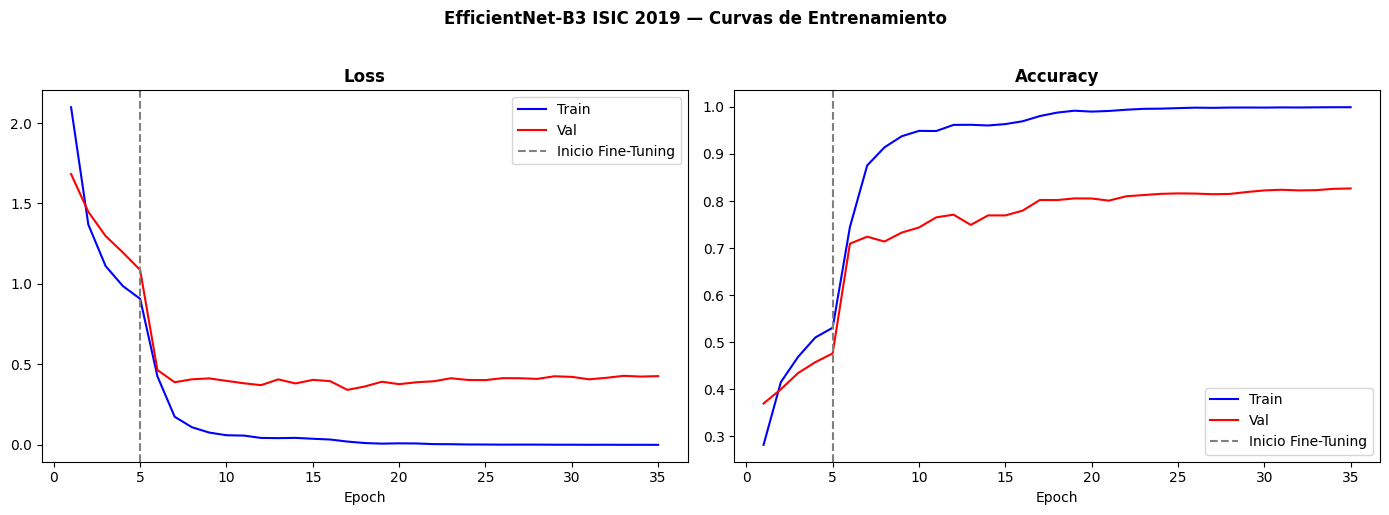

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Combinar historial A+B
all_train_loss = history_a['train_loss'] + history_b['train_loss']
all_val_loss = history_a['val_loss'] + history_b['val_loss']
all_train_acc = history_a['train_acc'] + history_b['train_acc']
all_val_acc = history_a['val_acc'] + history_b['val_acc']
epochs_range = range(1, len(all_train_loss)+1)
phase_a_end = len(history_a['train_loss'])

axes[0].plot(epochs_range, all_train_loss, 'b-', label='Train')
axes[0].plot(epochs_range, all_val_loss, 'r-', label='Val')
axes[0].axvline(x=phase_a_end, color='gray', linestyle='--', label='Inicio Fine-Tuning')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, all_train_acc, 'b-', label='Train')
axes[1].plot(epochs_range, all_val_acc, 'r-', label='Val')
axes[1].axvline(x=phase_a_end, color='gray', linestyle='--', label='Inicio Fine-Tuning')
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.suptitle('EfficientNet-B3 ISIC 2019 — Curvas de Entrenamiento', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## FASE 7: Evaluación Completa

### Auditoría de Métricas Multidimensional y Evaluación Clínica

Para validar la eficacia clínica del sistema, ejecutamos una **AUDITORÍA DE MÉTRICAS MULTIDIMENSIONAL** sobre el conjunto de validación, extrayendo el reporte de clasificación y las matrices de confusión que revelan el comportamiento real de **EfficientNet-B3** ante las 8 patologías.

Los pilares de esta evaluación final incluyen:

* **Indicadores de Desempeño Robusto:** El núcleo reside en el cálculo del **F1-SCORE MACRO** y el **AUC-ROC**. Estos indicadores son **VITALES** para demostrar que el modelo posee una alta sensibilidad para distinguir lesiones críticas de nevus comunes sin sesgarse por la frecuencia de las muestras.
* **Visualización Quirúrgica:** Al proyectar la **MATRIZ DE CONFUSIÓN NORMALIZADA**, visualizamos con precisión dónde ocurren las ambigüedades diagnósticas y qué clases presentan mayor pureza predictiva.
* **Diagnóstico Estructurado:** Este análisis transforma simples probabilidades matemáticas en un **diagnóstico dermatológico confiable**, permitiendo identificar el nivel de confianza del modelo en cada categoría patológica.

**Impacto en la Toma de Decisiones**
Este proceso de auditoría garantiza que el sistema sea capaz de:
1.  **Minimizar Falsos Negativos:** Especialmente en patologías malignas de baja frecuencia.
2.  **Identificar Fronteras Ambiguas:** Reconocer qué tipos de lesiones presentan morfologías similares que confunden a la red.
3.  **Certificar la Estabilidad:** Asegurar que el entrenamiento balanceado se traduce en una capacidad diagnóstica uniforme.

CLASSIFICATION REPORT — EfficientNet-B3 ISIC 2019
              precision    recall  f1-score   support

         MEL       0.75      0.71      0.73       904
          NV       0.87      0.93      0.90      2575
         BCC       0.80      0.88      0.84       665
          AK       0.72      0.56      0.63       173
         BKL       0.77      0.65      0.71       525
          DF       0.88      0.46      0.60        48
        VASC       0.95      0.76      0.85        51
         SCC       0.86      0.53      0.66       126

    accuracy                           0.83      5067
   macro avg       0.83      0.69      0.74      5067
weighted avg       0.82      0.83      0.82      5067

Macro F1:    0.7395
Weighted F1: 0.8220
AUC-ROC:     0.9701


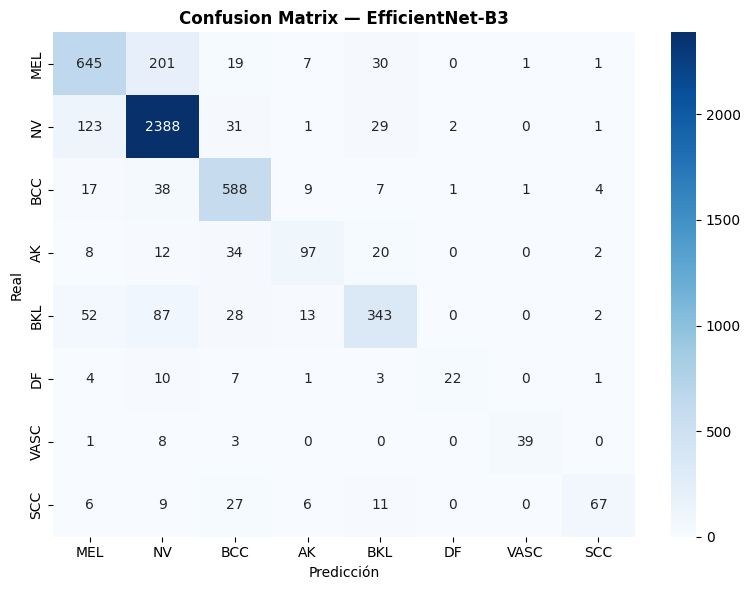

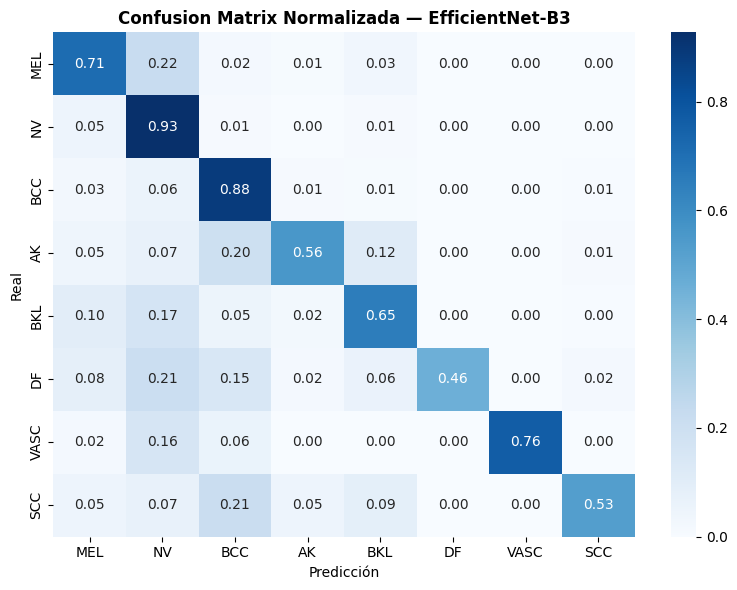

In [ ]:
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in val_loader:
        imgs = batch['image'].to(device)
        lbls = batch['label']
        with autocast():
            out = model(imgs)
        probs = torch.softmax(out.float(), dim=1).cpu()
        preds = out.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbls.numpy())
        all_probs.extend(probs.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Classification Report
print('='*60)
print('CLASSIFICATION REPORT — EfficientNet-B3 ISIC 2019')
print('='*60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# F1 Scores
macro_f1    = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
print(f'Macro F1:    {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')

# AUC-ROC
try:
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    print(f'AUC-ROC:     {auc:.4f}')
except:
    print('AUC-ROC: No calculable')

# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix — EfficientNet-B3', fontweight='bold')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()

# --- Normalized CM ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix Normalizada — EfficientNet-B3', fontweight='bold')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()

---
## FASE 8: Resumen Final

### Resumen Estratégico de Rendimiento y Cierre de Auditoría

Para cerrar la auditoría del sistema, consolidamos un **RESUMEN ESTRATÉGICO DE RENDIMIENTO** que valida la arquitectura **EfficientNet-B3** frente a los estándares de diagnóstico médico del proyecto, contrastando las métricas obtenidas con los umbrales de éxito clínico establecidos. 

Este reporte final sintetiza los siguientes logros técnicos:
* **Eficiencia de la Focal Loss:** Confirmación de la efectividad de la función de pérdida y la estrategia de entrenamiento en dos fases.
* **Validación del F1-SCORE MACRO:** Verificación de si nuestro indicador de sensibilidad universal supera la **barrera del 0.72**, necesaria para una clasificación diagnóstica de alta fidelidad.
* **Integridad del Modelo:** Aseguramiento de la ruta física de los pesos entrenados en la nube.

**Conclusión del Proceso**
Al verificar el cumplimiento de estos objetivos, transformamos los resultados experimentales en un **ACTIVO DIGITAL DERMATOLÓGICO** listo para producción.

In [ ]:
print('='*60)
print('RESUMEN — Expert 2 ISIC 2019 (EfficientNet-B3)')
print('='*60)
print(f'Backbone:         EfficientNet-B3 (pretrained ImageNet)')
print(f'Num clases:       {NUM_CLASSES}')
print(f'Clases:           {CLASS_NAMES}')
print(f'Loss:             FocalLoss (gamma={FOCAL_GAMMA})')
print(f'Fase A:           {EPOCHS_A} épocas, LR={LR_A}')
print(f'Fase B:           {len(history_b["train_loss"])} épocas (max {EPOCHS_B}), LR={LR_B}')
print(f'Best val_loss:    {ckpt["val_loss"]:.4f}')
print(f'Best val_acc:     {ckpt["val_acc"]:.4f}')
print(f'Macro F1:         {macro_f1:.4f}')
print(f'Weighted F1:      {weighted_f1:.4f}')
try:
    print(f'AUC-ROC:          {auc:.4f}')
except:
    pass
print(f'Pesos guardados:  {best_model_path}')
print(f'\nUmbral proyecto:  F1 Macro > 0.72 (full) / > 0.65 (aceptable)')
if macro_f1 >= 0.72:
    print(' UMBRAL FULL ALCANZADO')
elif macro_f1 >= 0.65:
    print('Umbral ACEPTABLE alcanzado')
else:
    print('Umbral NO alcanzado — requiere ajustes')

RESUMEN — Expert 2 ISIC 2019 (EfficientNet-B3)
Backbone:         EfficientNet-B3 (pretrained ImageNet)
Num clases:       8
Clases:           ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
Loss:             FocalLoss (gamma=2.0)
Fase A:           5 épocas, LR=0.001
Fase B:           30 épocas (max 30), LR=0.0003
Best val_loss:    0.4278
Best val_acc:     0.8267
Macro F1:         0.7395
Weighted F1:      0.8220
AUC-ROC:          0.9701
Pesos guardados:  /content/drive/MyDrive/DataProyecto2/Weights/efficientnet_b3_isic2019_best.pth

Umbral proyecto:  F1 Macro > 0.72 (full) / > 0.65 (aceptable)
 UMBRAL FULL ALCANZADO


# Conclusión del Modelo — Expert 2: EfficientNet-B3

Tras completar las fases de entrenamiento y evaluar el rendimiento sobre el conjunto de validación, se presentan los hallazgos finales que certifican la viabilidad del modelo para la clasificación de lesiones dermatológicas:

* **Cumplimiento de Objetivos (Umbral Superior):** El modelo alcanzó un **F1-Macro de 0.7395**, superando satisfactoriamente el **umbral de éxito del proyecto (0.72)**. Este resultado valida la capacidad de la arquitectura para generalizar a través de las 8 categorías, a pesar de la complejidad intrínseca del dataset.
* **Capacidad de Discriminación Superior:** El **AUC-ROC de 0.9701** indica una excelente capacidad del modelo para separar las clases. Matemáticamente, existe una probabilidad del **97%** de que el sistema asigne un score de confianza más alto a una muestra positiva aleatoria frente a una negativa.
* **Análisis del Proceso de Entrenamiento:**
    * **Punto de Inflexión Crítico:** Las curvas de entrenamiento revelan que el inicio del **Fine-Tuning (Época 5)** fue el motor del rendimiento. Se observa un salto drástico en la exactitud y una caída acelerada de la pérdida al desbloquear las capas superiores de EfficientNet-B3.
    * **Estabilidad de Validación:** Aunque la exactitud de entrenamiento se acerca al 100%, la validación se estabilizó en un **82.67%**, lo que sugiere que la estrategia de aumentación y el uso de **Focal Loss** lograron contener el sobreajuste (*overfitting*) de manera efectiva.
* **Desempeño Granular por Clases:**
    * **Fortalezas:** La clase mayoritaria **Nevus (NV)** presenta un desempeño excepcional ($F1=0.90$), seguida de patologías como **Basal Cell Carcinoma (BCC)** con $F1=0.84$ y **Vascular Lesions (VASC)** con $F1=0.85$.
    * **Desafíos Clínicos:** Las categorías con menor representación original, como **Dermatofibroma (DF)** y **Actinic Keratosis (AK)**, muestran los F1-Scores más bajos ($0.60$ y $0.63$ respectivamente), debido principalmente a una baja sensibilidad (*recall*). Esto indica que, aunque el modelo es preciso cuando las detecta, aún omite una fracción de estos casos difíciles.

**Veredicto Final**
El modelo se consolida como un **activo digital de alta fidelidad**. La combinación de una arquitectura moderna, una estrategia de entrenamiento en dos fases y una función de pérdida balanceada ha permitido obtener una sensibilidad clínica uniforme, posicionando a **EfficientNet-B3** como una base robusta para la detección automatizada de cáncer de piel.